# Desafio 06: Organizando e analisando dados de um Airbnb
*link do Desafio: https://dncgroupbr.notion.site/Desafio-Organizando-e-analisando-dados-de-um-Airbnb-1c81b4d4252c8063a5e8cc402d69dab4


**Tarefas a serem executadas**


1.   Importação correta dos arquivos com pandas, verificação das primeiras linhas, tipos de dados e aplicação correta do merge entre os DataFrames.

2.   Identificação dos valores nulos com isnull().sum() e aplicação adequada de preenchimento com média ou moda. Uso criterioso do dropna() quando necessário.
    
3.   Visualização com boxplot e uso correto do método do IQR para definir limites e remover valores extremos de forma consistente.

4.   Conversão de variáveis categóricas com .astype('category').cat.codes. Interpretação clara dos códigos gerados e, opcionalmente, uso de mapeamento para facilitar a leitura.

##Importando bibliotecas e dados

In [ ]:
#installing the most recently version od pandas profiling
!pip install ydata-profiling

In [ ]:
#used for data manipulation and metrics
import numpy as np
import pandas as pd
import calendar
from ydata_profiling import ProfileReport
from datetime import datetime

#graphic visualization of the data
import seaborn as sns
import matplotlib.pyplot as plt

#
from sklearn import metrics
from sklearn.preprocessing import scale, StandardScaler, OneHotEncoder, OrdinalEncoder

In [ ]:
#Review
urlReview = 'https://drive.google.com/file/d/1UMiA1XboPvBeP415GOoxRIIV_wMY40VJ/view?usp=sharing'
urlReview = 'https://drive.google.com/uc?id=' + urlReview.split('/')[-2]
dfReview = pd.read_csv(urlReview, encoding='unicode_escape')

#Listings
urlListings = 'https://drive.google.com/file/d/1ZXLikeMG5pOfLse3miUAz3K_c36O_J1j/view?usp=sharing'
urlListings = 'https://drive.google.com/uc?id=' + urlListings.split('/')[-2]
dfListings = pd.read_csv(urlListings, encoding='unicode_escape')

## 1 - Leia o arquivo e inspecione os dados ##

In [ ]:
#Review head
dfReview.head()

,id,number_of_reviews,review_scores_rating
0,272335,367,4.92
1,272631,32,5.00
2,273363,5,5.00
3,273463,654,4.83
4,273496,60,4.80


In [ ]:
#Review info
dfReview.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32695 entries, 0 to 32694
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    32695 non-null  int64  
 1   number_of_reviews     32695 non-null  int64  
 2   review_scores_rating  32695 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 766.4 KB


In [ ]:
#Listings head
dfListings.head()

,id,neighbourhood_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price
0,271975,Vidigal,Entire home/apt,4,1.0,2.0,2.0,236.0
1,272335,Copacabana,Entire home/apt,4,1.0,1.0,1.0,723.0
2,272631,Copacabana,Private room,2,1.0,1.0,2.0,1146.0
3,273261,Leblon,Entire home/apt,6,3.5,3.0,3.0,6742.0
4,273363,Santa Teresa,Private room,1,1.0,1.0,1.0,61.0


In [ ]:
#Listings info
dfListings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      39499 non-null  int64  
 1   neighbourhood_cleansed  39499 non-null  object 
 2   room_type               39499 non-null  object 
 3   accommodates            39499 non-null  int64  
 4   bathrooms               36609 non-null  float64
 5   bedrooms                38976 non-null  float64
 6   beds                    36630 non-null  float64
 7   price                   36644 non-null  float64
dtypes: float64(4), int64(2), object(2)
memory usage: 2.4+ MB


In [ ]:
#Rename Column
dfListings.rename(columns={'id':'listings_id'})

,listings_id,neighbourhood_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price
0,271975,Vidigal,Entire home/apt,4,1.0,2.0,2.0,236.0
1,272335,Copacabana,Entire home/apt,4,1.0,1.0,1.0,723.0
2,272631,Copacabana,Private room,2,1.0,1.0,2.0,1146.0
3,273261,Leblon,Entire home/apt,6,3.5,3.0,3.0,6742.0
4,273363,Santa Teresa,Private room,1,1.0,1.0,1.0,61.0
...,...,...,...,...,...,...,...,...
39494,1319593870376466401,Copacabana,Entire home/apt,4,2.0,1.0,2.0,957.0
39495,1319611826461021550,Jacarezinho,Entire home/apt,8,1.0,1.0,1.0,288.0
39496,1319620401959854025,Copacabana,Entire home/apt,6,1.0,1.0,4.0,672.0
39497,1319650312466603776,Ipanema,Entire home/apt,6,1.5,2.0,1.0,1083.0


###Merge dos dados

In [ ]:
dfAir = dfListings.merge(right=dfReview, on="id", how="left")

In [ ]:
dfAir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      39499 non-null  int64  
 1   neighbourhood_cleansed  39499 non-null  object 
 2   room_type               39499 non-null  object 
 3   accommodates            39499 non-null  int64  
 4   bathrooms               36609 non-null  float64
 5   bedrooms                38976 non-null  float64
 6   beds                    36630 non-null  float64
 7   price                   36644 non-null  float64
 8   number_of_reviews       32695 non-null  float64
 9   review_scores_rating    32695 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 3.0+ MB


In [ ]:
#ProfileReport(df)

## 2 - Limpeza e Tratamento de Dados ##

In [ ]:
dfAir.isnull().sum()

,0
id,0
neighbourhood_cleansed,0
room_type,0
accommodates,0
bathrooms,2890
bedrooms,523
beds,2869
price,2855
number_of_reviews,6804
review_scores_rating,6804


In [ ]:
dfAir.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39499 entries, 0 to 39498
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      39499 non-null  int64  
 1   neighbourhood_cleansed  39499 non-null  object 
 2   room_type               39499 non-null  object 
 3   accommodates            39499 non-null  int64  
 4   bathrooms               36609 non-null  float64
 5   bedrooms                38976 non-null  float64
 6   beds                    36630 non-null  float64
 7   price                   36644 non-null  float64
 8   number_of_reviews       32695 non-null  float64
 9   review_scores_rating    32695 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 3.0+ MB


In [ ]:
#Filling NaN numbers with Avg Values
cols = ['bathrooms','bedrooms','beds','price','number_of_reviews','review_scores_rating']
dfAir[cols] = dfAir[cols].fillna(dfAir[cols].mean())

In [ ]:
dfAir.isnull().sum()

,0
id,0
neighbourhood_cleansed,0
room_type,0
accommodates,0
bathrooms,0
bedrooms,0
beds,0
price,0
number_of_reviews,0
review_scores_rating,0


## 3 - Visualização com boxplot e uso correto do método do IQR para definir limites e remover valores extremos de forma consistente. ##

<Axes: >

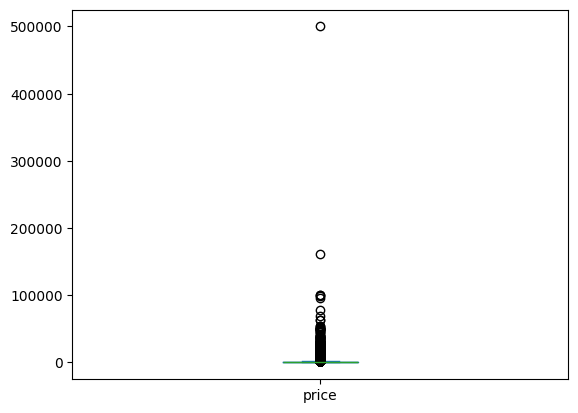

In [ ]:
#boxplot to import data, for me it's price and accommodates
dfAir['price'].plot(kind='box')

<Axes: >

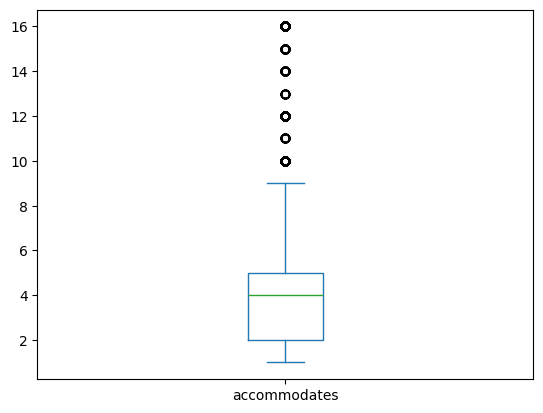

In [ ]:
#boxplot to import data, for me it's price and accommodates
dfAir['accommodates'].plot(kind='box')

IQR = Q3 - Q1 : Interquartile Range

Limite Inferior = Q1 - 1.5 * IQR

Limite Superior = Q3 +1.5 * IQR

In [ ]:
dfPrice = dfAir['price']
dfAccommodates = dfAir['accommodates']

Q1p = dfPrice.quantile(0.25)
Q1a = dfAccommodates.quantile(0.25)
Q3p = dfPrice.quantile(0.75)
Q3a = dfAccommodates.quantile(0.75)
print(Q1p)

429.0


In [ ]:
IQRprice = Q3p - Q1p
IQRaccommodates = Q3a - Q1a
print('IQR price:', IQRprice,'IQR Accommodates', IQRaccommodates)

IQR price: 798.1217116035368 IQR Accommodates 3.0


In [ ]:
limite_superiorPrice = Q3p + 1.5 * IQRprice
limite_inferiorPrice = Q1p - 1.5 * IQRprice
print('Limite Superior = ',limite_superiorPrice, ',Limite Inferior = ',limite_inferiorPrice)

Limite Superior =  2424.304279008842 ,Limite Inferior =  -768.1825674053052


In [ ]:
#As the minor value was negative, we will use 0
dfAirIQR = dfAir[(dfAir['price']<limite_superiorPrice)]

In [ ]:
dfAirIQR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36505 entries, 0 to 39498
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      36505 non-null  int64  
 1   neighbourhood_cleansed  36505 non-null  object 
 2   room_type               36505 non-null  object 
 3   accommodates            36505 non-null  int64  
 4   bathrooms               36505 non-null  float64
 5   bedrooms                36505 non-null  float64
 6   beds                    36505 non-null  float64
 7   price                   36505 non-null  float64
 8   number_of_reviews       36505 non-null  float64
 9   review_scores_rating    36505 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 3.1+ MB


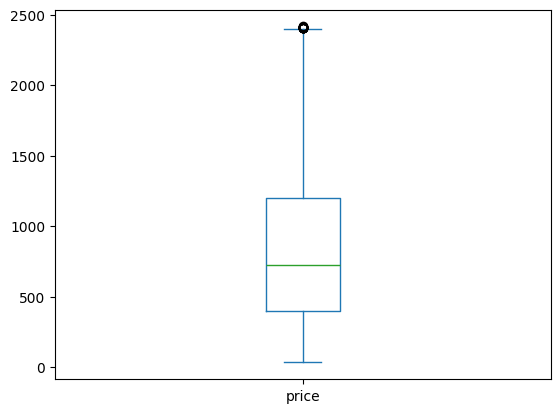

In [ ]:
dfAirIQR['price'].plot(kind='box');

## 4 - Transformando Dados Categóricos ##



In [ ]:
dfAirIQR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36505 entries, 0 to 39498
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      36505 non-null  int64  
 1   neighbourhood_cleansed  36505 non-null  object 
 2   room_type               36505 non-null  object 
 3   accommodates            36505 non-null  int64  
 4   bathrooms               36505 non-null  float64
 5   bedrooms                36505 non-null  float64
 6   beds                    36505 non-null  float64
 7   price                   36505 non-null  float64
 8   number_of_reviews       36505 non-null  float64
 9   review_scores_rating    36505 non-null  float64
dtypes: float64(6), int64(2), object(2)
memory usage: 3.1+ MB


In [ ]:
dfAirIQR['room_type'] = dfAirIQR['room_type'].astype('category').cat.codes
dfAirIQR.head()

/tmp/ipykernel_72629/3070851955.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfAirIQR['room_type'] = dfAirIQR['room_type'].astype('category').cat.codes


,id,neighbourhood_cleansed,room_type,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
0,271975,Vidigal,0,4,1.0,2.0,2.0,236.0,24.1321,4.816146
1,272335,Copacabana,0,4,1.0,1.0,1.0,723.0,367.0000,4.920000
2,272631,Copacabana,2,2,1.0,1.0,2.0,1146.0,32.0000,5.000000
4,273363,Santa Teresa,2,1,1.0,1.0,1.0,61.0,5.0000,5.000000
5,273463,Lagoa,0,6,2.0,2.0,6.0,1411.0,654.0000,4.830000


In [ ]:
dfAirIQR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36505 entries, 0 to 39498
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      36505 non-null  int64  
 1   neighbourhood_cleansed  36505 non-null  object 
 2   room_type               36505 non-null  int8   
 3   accommodates            36505 non-null  int64  
 4   bathrooms               36505 non-null  float64
 5   bedrooms                36505 non-null  float64
 6   beds                    36505 non-null  float64
 7   price                   36505 non-null  float64
 8   number_of_reviews       36505 non-null  float64
 9   review_scores_rating    36505 non-null  float64
dtypes: float64(6), int64(2), int8(1), object(1)
memory usage: 2.8+ MB


In [ ]:
dfAirIQR.describe()

,id,room_type,accommodates,bathrooms,bedrooms,beds,price,number_of_reviews,review_scores_rating
count,3.650500e+04,36505.000000,36505.000000,36505.000000,36505.000000,36505.000000,36505.000000,36505.000000,36505.000000
mean,6.848114e+17,0.426544,3.746692,1.400314,1.432503,2.206513,815.409245,24.064355,4.816183
std,5.201743e+17,0.831742,1.962116,0.707442,0.877597,1.613800,506.732227,43.719568,0.280457
min,1.787800e+04,0.000000,1.000000,0.000000,0.000000,0.000000,33.000000,0.000000,0.000000
25%,4.224761e+07,0.000000,2.000000,1.000000,1.000000,1.000000,400.000000,1.000000,4.812309
50%,8.476722e+17,0.000000,4.000000,1.000000,1.000000,2.000000,723.000000,9.000000,4.816146
75%,1.143617e+18,0.000000,4.000000,2.000000,2.000000,3.000000,1200.000000,24.132100,5.000000
max,1.320520e+18,3.000000,16.000000,20.000000,30.000000,50.000000,2418.000000,710.000000,5.000000


In [ ]:
dfAirIQR.columns

Index(['id', 'neighbourhood_cleansed', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'price', 'number_of_reviews',
       'review_scores_rating'],
      dtype='object')